**Scenario**
We’re modeling the probability of diabetes worsening based on patient data (age, BMI, HbA1c) from multiple clinics. The model:
Uses a hierarchical structure to account for clinic-specific effects.

Incorporates patient-level predictors in a logistic regression framework.

Estimates posterior probabilities of progression and visualizes results for clinical decision-making.



In [1]:
# Imports
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

# Step 1: Generate initial training data
np.random.seed(42)
n_patients = 200
n_clinics = 5

clinics = np.random.randint(0, n_clinics, n_patients)
age = stats.norm(50, 10).rvs(n_patients)
bmi = stats.norm(28, 5).rvs(n_patients)
hba1c_base = stats.norm(6, 1).rvs(n_patients)
hba1c = hba1c_base + 0.02 * age + 0.1 * bmi + stats.norm(0, 0.5).rvs(n_patients)
progression = (hba1c > 7).astype(int)

train_data = pd.DataFrame({
    "clinic": clinics,
    "age": age,
    "bmi": bmi,
    "hba1c": hba1c,
    "progression": progression
})



In [2]:
train_data[train_data['progression'] == 0]

,clinic,age,bmi,hba1c,progression
23,0,57.412406,23.228049,6.497073,0
56,3,30.636238,23.622191,5.588913,0
80,4,56.351126,29.703076,6.876284,0
157,4,60.606386,23.906615,6.597423,0


In [4]:
'''
# Imports
import pymc as pm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from scipy import stats

# Step 1: Generate initial training data
np.random.seed(42)
n_patients = 200
n_clinics = 5

clinics = np.random.randint(0, n_clinics, n_patients)
age = stats.norm(50, 10).rvs(n_patients)
bmi = stats.norm(28, 5).rvs(n_patients)
hba1c_base = stats.norm(6, 1).rvs(n_patients)
hba1c = hba1c_base + 0.02 * age + 0.1 * bmi + stats.norm(0, 0.5).rvs(n_patients)
progression = (hba1c > 7).astype(int)

train_data = pd.DataFrame({
    "clinic": clinics,
    "age": age,
    "bmi": bmi,
    "hba1c": hba1c,
    "progression": progression
})
'''

# Standardize predictors
train_data["age_std"] = (train_data["age"] - train_data["age"].mean()) / train_data["age"].std()
train_data["bmi_std"] = (train_data["bmi"] - train_data["bmi"].mean()) / train_data["bmi"].std()
train_data["hba1c_std"] = (train_data["hba1c"] - train_data["hba1c"].mean()) / train_data["hba1c"].std()

# Step 2: Define and fit the hierarchical model
with pm.Model() as diabetes_model:
    mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1)
    sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1)
    mu_beta = pm.Normal("mu_beta", mu=0, sigma=1, shape=3)
    sigma_beta = pm.HalfNormal("sigma_beta", sigma=1, shape=3)

    alpha = pm.Normal("alpha", mu=mu_alpha, sigma=sigma_alpha, shape=n_clinics)
    beta = pm.Normal("beta", mu=mu_beta, sigma=sigma_beta, shape=(n_clinics, 3))

    logit_p = (alpha[train_data["clinic"]] +
               beta[train_data["clinic"], 0] * train_data["age_std"] +
               beta[train_data["clinic"], 1] * train_data["bmi_std"] +
               beta[train_data["clinic"], 2] * train_data["hba1c_std"])

    progression_obs = pm.Bernoulli("progression_obs", logit_p=logit_p, observed=train_data["progression"])
    #approx = pm.fit(n=50000, method='advi')
    approx = pm.fit(n=10000, method="advi", obj_optimizer=pm.adam(learning_rate=1e-3))
    trace = approx.sample(2000)
    #trace = pm.sample(2000, tune=1000, target_accept=0.99, return_inferencedata=True)

'''
# Step 3: Generate "new" patient data for prediction
n_new = 5
new_clinics = np.random.randint(0, n_clinics, n_new)
new_age = stats.norm(50, 10).rvs(n_new)
new_bmi = stats.norm(28, 5).rvs(n_new)
new_hba1c = stats.norm(6.5, 1).rvs(n_new) + 0.02 * new_age + 0.1 * new_bmi

new_data = pd.DataFrame({
    "clinic": new_clinics ,
    "age": new_age,
    "bmi": new_bmi ,
    "hba1c": new_hba1c
})
'''




Finished [100%]: Average Loss = 32.619


'\n# Step 3: Generate "new" patient data for prediction\nn_new = 5\nnew_clinics = np.random.randint(0, n_clinics, n_new)\nnew_age = stats.norm(50, 10).rvs(n_new)\nnew_bmi = stats.norm(28, 5).rvs(n_new)\nnew_hba1c = stats.norm(6.5, 1).rvs(n_new) + 0.02 * new_age + 0.1 * new_bmi\n\nnew_data = pd.DataFrame({\n    "clinic": new_clinics ,\n    "age": new_age,\n    "bmi": new_bmi ,\n    "hba1c": new_hba1c\n})\n'

In [5]:
new_data = pd.DataFrame({
    "clinic": [0, 2, 3, 1, 1],
    "age": [23, 43, 51, 56, 65],
    "bmi": [20, 24, 26.1, 31, 29],
    "hba1c": [4.1, 7.8, 8.4, 9.1, 10.2]
})
# Standardize new data using training data stats
new_data["age_std"] = (new_data["age"] - train_data["age"].mean()) / train_data["age"].std()
new_data["bmi_std"] = (new_data["bmi"] - train_data["bmi"].mean()) / train_data["bmi"].std()
new_data["hba1c_std"] = (new_data["hba1c"] - train_data["hba1c"].mean()) / train_data["hba1c"].std()

print("\nNew Patient Data:")
print(new_data[["clinic", "age", "bmi", "hba1c"]])

# Step 4: Predict progression for new patients
with diabetes_model:
    logit_p_new = (alpha[new_data["clinic"]] +
                   beta[new_data["clinic"], 0] * new_data["age_std"] +
                   beta[new_data["clinic"], 1] * new_data["bmi_std"] +
                   beta[new_data["clinic"], 2] * new_data["hba1c_std"])
    p_progression_new = pm.Deterministic("p_progression_new", pm.math.invlogit(logit_p_new))
    trace_new = pm.sample_posterior_predictive(trace, var_names=["p_progression_new"])


New Patient Data:
   clinic  age   bmi  hba1c
0       0   23  20.0    4.1
1       2   43  24.0    7.8
2       3   51  26.1    8.4
3       1   56  31.0    9.1
4       1   65  29.0   10.2


Sampling: []


In [6]:
az.summary(trace)

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,3.043,0.474,2.122,3.902,0.011,0.007,2024.0,1919.0,NaN
mu_beta[0],-0.037,0.277,-0.549,0.464,0.006,0.004,1904.0,2139.0,NaN
mu_beta[1],-0.159,0.273,-0.726,0.329,0.006,0.005,1800.0,1829.0,NaN
mu_beta[2],0.818,0.273,0.293,1.305,0.006,0.004,1931.0,1925.0,NaN
alpha[0],3.923,0.634,2.593,5.000,0.014,0.010,2124.0,1968.0,NaN
alpha[1],4.131,0.776,2.640,5.551,0.017,0.012,1994.0,1834.0,NaN
alpha[2],4.203,0.715,2.899,5.584,0.015,0.011,2150.0,1880.0,NaN
alpha[3],4.099,0.643,2.890,5.266,0.014,0.010,2028.0,1960.0,NaN
alpha[4],3.622,0.652,2.319,4.782,0.015,0.011,1918.0,1810.0,NaN
"beta[0, 0]",-0.384,0.455,-1.206,0.495,0.010,0.007,1981.0,1855.0,NaN


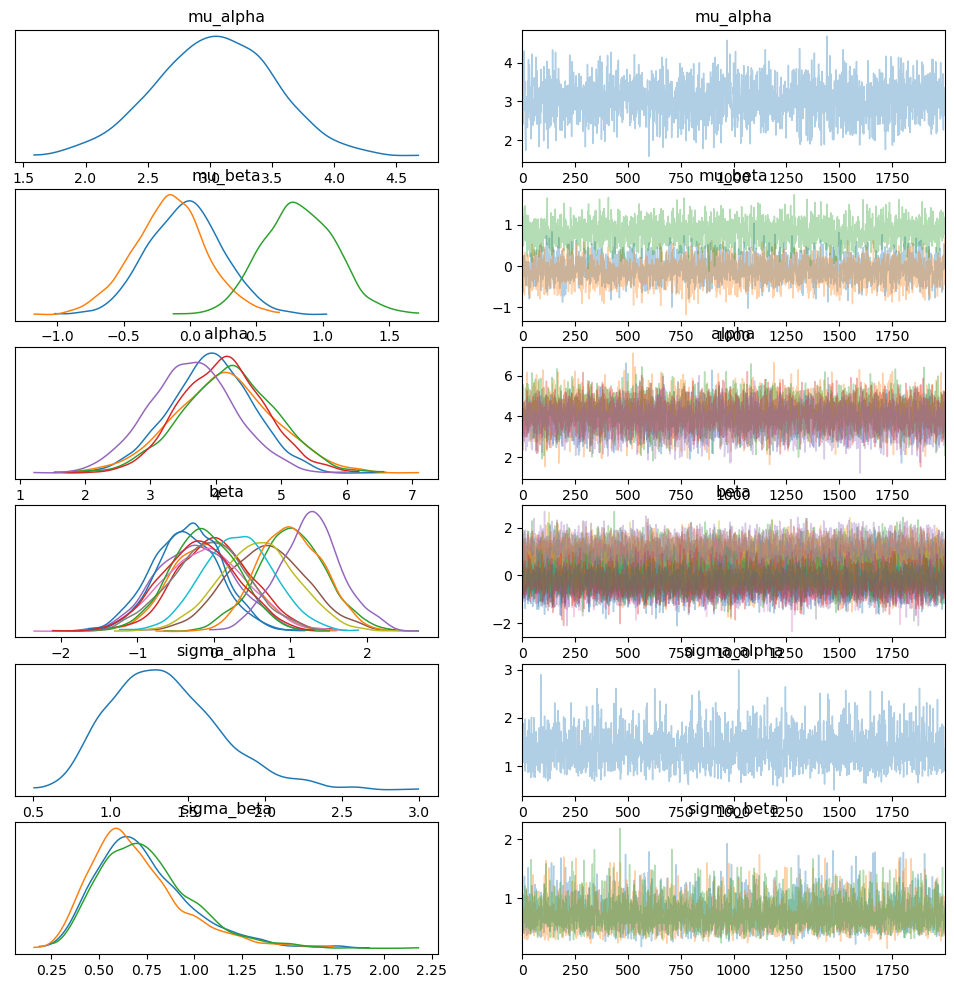

In [7]:
az.plot_trace(trace)
plt.show()

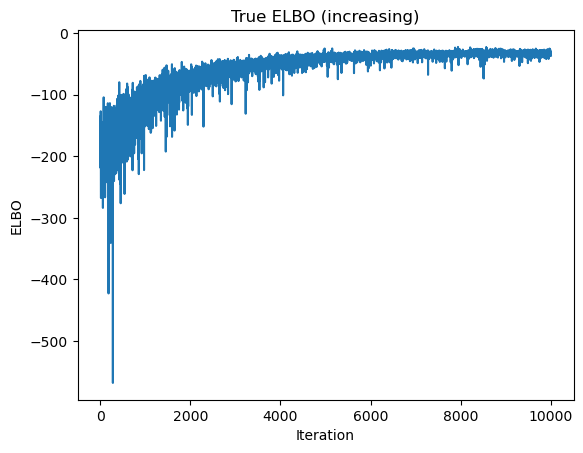

In [8]:
elbo_vals = approx.hist
plt.plot(-elbo_vals)
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.title("True ELBO (increasing)")
plt.show()


In [9]:
with diabetes_model:
    ppc = pm.sample_posterior_predictive(approx.sample(1000))

Sampling: [progression_obs]


In [10]:
with diabetes_model:
    logit_p_new = (alpha[train_data["clinic"]] +
                   beta[train_data["clinic"], 0] * train_data["age_std"] +
                   beta[train_data["clinic"], 1] * train_data["bmi_std"] +
                   beta[train_data["clinic"], 2] * train_data["hba1c_std"])
    p_progression_insample = pm.Deterministic("p_progression_insample", pm.math.invlogit(logit_p_new))
    trace_insample = pm.sample_posterior_predictive(trace, var_names=["p_progression_insample"])

Sampling: []


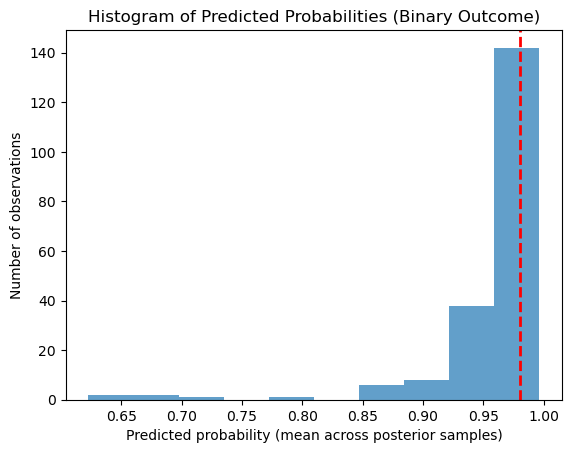

In [11]:
pred_means = trace_insample['posterior_predictive']['p_progression_insample'].mean(axis=1)

plt.hist(list(pred_means), bins=10, alpha=0.7)
plt.xlabel("Predicted probability (mean across posterior samples)")
plt.axvline(x=np.mean(train_data['progression']), color="red", linestyle="--", linewidth=2, label="Real data")
plt.ylabel("Number of observations")
plt.title("Histogram of Predicted Probabilities (Binary Outcome)")
plt.show()


Predictions and Clinical Decisions for New Patients:
Patient 1: Prob = 0.637
Patient 2: Prob = 0.947
Patient 3: Prob = 0.949
Patient 4: Prob = 0.962
Patient 5: Prob = 0.976


NameError: name 'n_new' is not defined

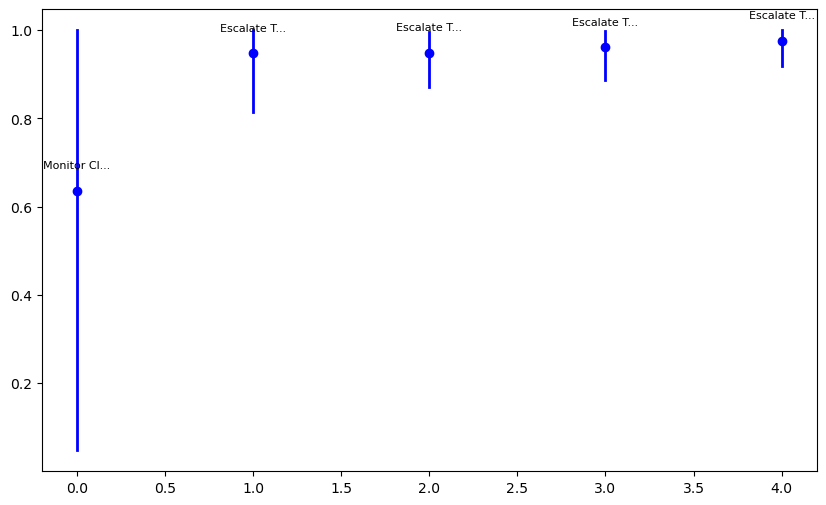

In [12]:
# Extract predictions
new_predictions = trace_new.posterior_predictive["p_progression_new"].mean(dim=["chain", "draw"]).values
new_hdi = az.hdi(trace_new.posterior_predictive["p_progression_new"], hdi_prob=0.95)

# Step 5: Clinical decision rules
def clinical_decision(prob):
    if prob > 0.7:
        return "Escalate Treatment (e.g., adjust meds, urgent consult)"
    elif prob > 0.3:
        return "Monitor Closely (e.g., frequent check-ups)"
    else:
        return "No Immediate Action (e.g., maintain current plan)"

print("\nPredictions and Clinical Decisions for New Patients:")
for i, (pred, hdi_vals) in enumerate(zip(new_predictions, new_hdi['p_progression_new'])):
    decision = clinical_decision(pred)
    print(f"Patient {i+1}: Prob = {pred:.3f}")
    #, 95% HDI = [{hdi_vals['p_progression_new'][0][0]:.3f}, {hdi_vals['p_progression_new'][0][1]:.3f}], Decision = {decision}")

# Step 6: Visualize predictions with decisions
plt.figure(figsize=(10, 6))
for i, (pred, hdi_vals) in enumerate(zip(new_predictions, new_hdi['p_progression_new'])):
    plt.plot([i, i], hdi_vals, "b-", lw=2)
    plt.plot(i, pred, "bo")
    plt.text(i, pred + 0.05, clinical_decision(pred)[:10] + "...", ha="center", fontsize=8)
plt.xticks(range(n_new), [f"Patient {i+1}" for i in range(n_new)])
plt.ylabel("Probability of Progression")
plt.title("Predicted Progression Risk with Clinical Decisions (New Patients)")
plt.ylim(0, 1.2)
plt.show()

Explanation of Changes
Training Data:
Initial dataset (train_data) is used to fit the model, as before.

New Data:
A small batch of "new" patients (new_data) is generated with similar distributions but independent of the training set.

Standardized using the training data’s mean and standard deviation to ensure consistency.

Prediction:
Posterior predictive sampling computes progression probabilities for new patients using the fitted model’s parameters (alpha, beta).

Clinical Decisions:
A simple rule-based function assigns actions based on risk thresholds:
> 0.7: Escalate treatment (e.g., adjust medication, refer to specialist).

0.3–0.7: Monitor closely (e.g., schedule follow-ups).

< 0.3: No immediate action (e.g., continue current management).

These thresholds are arbitrary but could be tuned based on clinical guidelines.

Visualization:
The plot shows each new patient’s risk with 95% HDI and a label indicating the decision.

